# 02 Logistic Regression — Coding Lab

### 2.1 Project Outline

<div align="center">
<img src="attachment:4454529e-4837-4d46-89d6-58e0c5646806.jpeg" width="700"/>
</div>

The purpose of the given notebook is to demonstrate the usage of Machine Learning techniques with the help of practical example. 

As a student, you will learn about fundamentals of scikit-learn library and the methods of dealing with datasets. Furthermore, you will gain 
some practical experience related to Logistic Regression with the help of demo project. 

Machine Learning is full of practical use cases that can automate daily tasks. There are a lot problems in industry and research that can be easily handled with the help of ML. One of such problems is detecting spam emails. Email is the worldwide use of communication application. The main reason is based on the ease of use compared to communication applications. However, its inability to detect whether the mail content is either spam or ham degrade its performance. Nowadays, lot of cases have been reported regarding stealing of personal information or phishing activities via email from the user. This project will discuss how machine learning help in spam detection. This is the example of so called binary classification problem, where an algorithm tries to determine whether the input belongs to one of the two classes. Binary classifier will be used to classify the text into two different categories; spam and ham. The algorithm will predict the score more accurately. The objective of developing this model is to detect and score word faster and accurately.

In this project we will learn how to use Logistic Regression algorithm to detect spam emails. We also will implement basic ML and data analysis techniques to better understand the process. 

If you're ready, let's dive in! 🚀

**How to use this lab:** Answer each exercise by replacing its `# Your code here` comment. Run the cells in order. The plotting cells are already provided.

### 2.2 Project Setup

Before starting the implementation, you should firstly install required libraries and packages to your python environment. If you don't have the libraries such as pandas, numpy etc. you can install them using the following line: just unconment them.


In [3]:
# run once, restart your notebook and continue from the next cell 
#Thank you for the reference video

%pip install -q pandas numpy matplotlib seaborn scikit-learn      

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


The dataset is provided locally. Put `email.csv` in a `data` folder beside this notebook. The Kaggle installation and download commands are commented out below; this lab reads the local file.

In [68]:
# The dataset is already in the local data folder.
%pip install -q kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [69]:
from pathlib import Path

# The Kaggle download from the guide is disabled in this lab:
# import kagglehub
# csv_path = kagglehub.dataset_download(
#     "ashfakyeafi/spam-email-classification",
#     path="email.csv",
#     output_dir=str(Path.cwd() / "data"),
# )

csv_path = Path("data") / "email.csv"
if not csv_path.is_file():
    raise FileNotFoundError("Place email.csv in the data folder beside this notebook.")
print("Dataset file:", csv_path)

Dataset file: data\email.csv


### 2.3 Importing required libraries

Before starting any project, you should import required libraries and modules to your notebook. For this project we will use several built-in libraries. We will use pandas for handling with tabular datasets and numpy for fast matrix calculations. Additionally, we will use matplotlib and seaborn libraries for visualization and interactive demonstrations. If you are unfamiliar with these libraries pls check the link in the reference section (it contains some good resources that you can read for further studies).


Note: there are some libraries that was not installed into the notebook in this section. It was done deliberately to show explicitly show you implementation steps. You will see this libraries in the next sections of the notebook. 

In [70]:
import numpy as np                               
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
# This line tell matplotlib to use preset appearance for plots.
# You can consider this as spesific plotting style. 

plt.style.use("ggplot")

### 2.4 Getting familiar with dataset

After installing the required packages, you can start exploring your dataset. Before implementing any model or technique it is recommended to explore basic features of the dataset such as the number of total samples (rows) and features (columns). You should also explore the data types of the features and labels to understand the task and implement correct approaches. There are several commands that will help you to realize this. Let's explore the main ones.

**Exercise 1.** Read the local CSV file at `csv_path` into a DataFrame named `emails_df`.

In [72]:
emails_df=pd.read_csv(csv_path,encoding='utf-8')
# Your code here: load the CSV into emails_df

**Exercise 2.** Display the first 10 rows of `emails_df`.

In [73]:
# Your code here: display the first 10 rows
emails_df.head(10)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [74]:
# you can also print print all elements of the dataset by uncommenting this line

# emails_df

In [75]:
# shape of the dataset

emails_df.shape

(5573, 2)

In [76]:
# printing main features of dataset

emails_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5573 non-null   str  
 1   Message   5573 non-null   str  
dtypes: str(2)
memory usage: 542.3 KB


As you can see, the dataset contains 5573 rows and 2 columns in total. Columns contains information such as the labels and the email text.


We can further explore the dataset by counting the total numbers of each existing label and also print some examples of the emails. Let's implement these steps.

**Exercise 3.** How many messages are labeled `ham` and `spam`? Use pandas to count them.

In [77]:
# Your code here: count the ham and spam labels
emails_df["Category"].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [78]:
# last 10 elements of dataset

emails_df.tail()

,Category,Message
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name
5572,"{""mode"":""full""",isActive:false}


In [79]:
# 10th example from dataset --> you can print any element using the same strategy

print(emails_df["Message"][10])

I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.


We can see that there are 4825 ham and 747 spam messages. This means that there is imbalance in our data elements. In data science such datasets is called imbalanced datasets and it is very important problem that should be handled before modelling. If we don't solve imbalanced dataset problem our model will be trained mostly on the ham messages and it will be prone to predict ham messages for given input. Mathematically we say that in such cases model becomes biased. You will see what this all means at the end of project. Furthermore, we will try to solve this problem in our further implementations.

### 2.5 Handling wrong samples, null values and duplicates 

In previous example, we can see that there is one message with label {"moe:"full" which is located in the last row. It is wrong label type since messages can be only ham and spam types. So, we need to eleminate examples with wrongly typed data from our dataset. Let's do this first.

**Exercise 4.** The last row has an invalid label. Remove that row from `emails_df`.

In [ ]:
# Your code here: remove the final row and assign the result to emails_df
emails_df = emails_df.iloc[:-1]

In [81]:
emails_df.tail()

,Category,Message
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...
5571,ham,Rofl. Its true to its name


Now let's check for missing values in the dataset. If our dataset contains values such as null and NaN, it means they are somehow "empty". We need to find and handle them as well, as they can create additional problems during modelling.

**Exercise 5.** How many missing values are there in the entire DataFrame?

In [82]:
# Your code here: count all missing values in emails_df
emails_df.isna().sum().sum()

np.int64(0)

As you can see, we don't have null values. Now, we can check for duplicated samples. If our dataset contains duplicated rows, it means we are considering the same information twice. In the modelling part, giving such examples to the model can create bias related to similar expressions. Consequently, we need to handle duplicates as well.

**Exercise 6.** Count the duplicate rows in `emails_df`.

In [83]:
# Your code here: count duplicated rows
emails_df.duplicated().sum()

np.int64(415)

In [84]:
# duplicates in percentage

emails_df.duplicated().sum() / emails_df.shape[0]

np.float64(0.07447954055994258)

As you can see, there are 415 duplicated samples in our dataset which is approximately 7%. So, we need to eleminate duplicates as they give no new information about the samples. 

**Exercise 7.** Remove duplicate rows from `emails_df`.

In [85]:
# Your code here: drop duplicate rows from emails_df
emails_df=emails_df.drop_duplicates()

In [86]:
# checking duplicates

emails_df.duplicated().sum()

np.int64(0)

### 2.6 Visualizing categories

So, we now have no duplicates in our data. Now let's look at our labels again. The code below shows that despite reducing duplicates we again have imbalanced dataset.

In [87]:
emails_df["Category"].value_counts()

Category
ham     4516
spam     641
Name: count, dtype: int64

In [88]:
# printing the categories as percentages 
 
emails_df["Category"].value_counts(normalize=True) * 100

Category
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64

We can also make some visualization about the imbalanced categories. Let's use pie-chart to visualize their amount

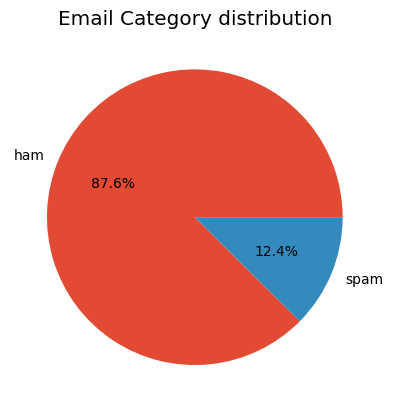

In [89]:
# implementation of pie-chart

emails_df["Category"].value_counts(normalize=True).plot(
    kind = "pie",
    autopct = "%1.1f%%"
)

plt.ylabel("")

plt.title("Email Category distribution")

plt.show()

### 2.7 Exploration of data

#### 2.7.1 Message Length

Now, let's continue exploration. Here, we need to logically think about what can be usefull information in our dataset that we need to consider. Try to answer the question:

*What can give us clue about the data and the relation between inputs (messages) and outputs (labels)?* 

One of the first things that comes to mind is to consider the length of the messages. Can labels be depended on the length of the messages? To find answer, we will create a new column (feature) containing this information.

**Exercise 8.** Add a `Message_Length` column containing the length of each message.

In [90]:
# Your code here: create the Message_Length column from the length of each Message
emails_df["Message_Length"]=emails_df["Message"].str.len()

In [91]:
emails_df.head()

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [92]:
# basic statistics about message length

emails_df["Message_Length"].describe()

count    5157.000000
mean       79.103936
std        58.382922
min         2.000000
25%        36.000000
50%        61.000000
75%       118.000000
max       910.000000
Name: Message_Length, dtype: float64

We can also plot the distribution of the message length to see them in visual form. For this purpose, let's implement histogram.

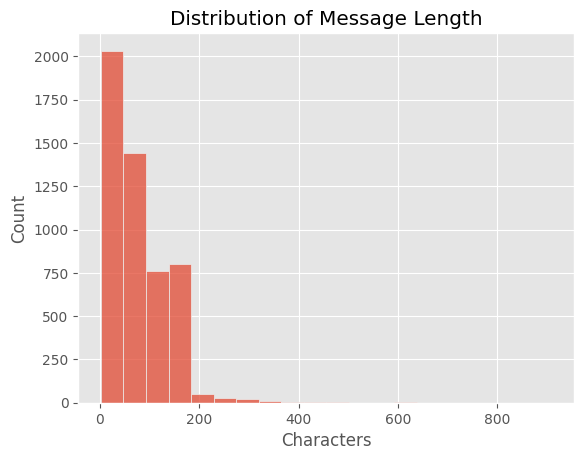

In [93]:
# implementation of histogram to describe message length distribution 

sns.histplot(emails_df["Message_Length"], bins=20)

plt.title("Distribution of Message Length")

plt.xlabel("Characters")

plt.show()

We can also create boxplots that describe the system distribution. In this example, compared to histograms, boxplot will show us distribution of each category as separate unit. (For more information check the reference)

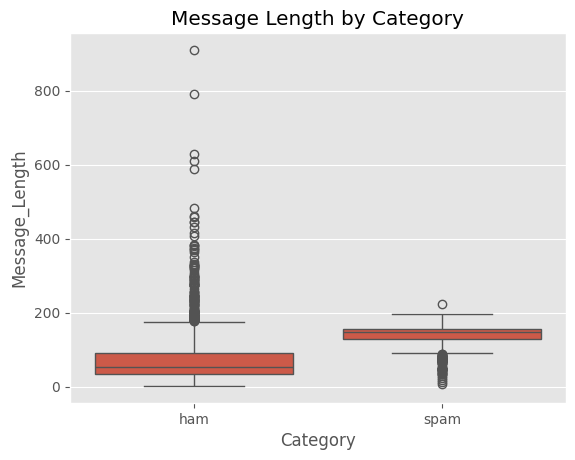

In [94]:
# implementation of boxplot
 
sns.boxplot(
    data = emails_df,
    x = "Category",
    y = "Message_Length"
)

plt.title("Message Length by Category")

plt.show()

The distributions show us interesting result. The length of the spam messages are longer compared to ham messages. This can be clue for our further exploration. For now we can print the mean values of length for each group. After this, we can plot the values in bargraph

In [95]:
# print the mean message length of each category 

emails_df.groupby("Category")["Message_Length"].mean()

Category
ham      70.869353
spam    137.118565
Name: Message_Length, dtype: float64

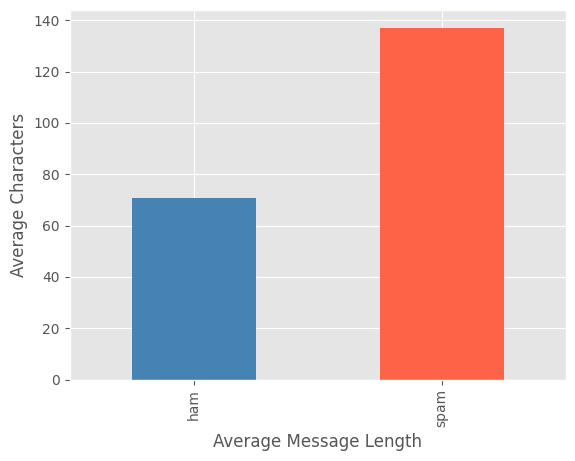

In [96]:
# plot category values in bar graph 

emails_df.groupby("Category")["Message_Length"].mean().plot(
    kind = "bar",
    color = ["steelblue", "tomato"]
)

plt.ylabel("Average Characters")

plt.xlabel("Average Message Length")

plt.show()

The printed results and plots show us new fact: on average the spam message are twice longer than ham message. This can be considered as useful information obtained with the help of EDA (Exploratory Data Analysis). Spam messages often contains promotional texts, links, disclaimers, unsubscribe notices, or repeated marketing language that pads out the message. On contrary, ham messages (legitimate personal/casual messages) tend to be short and to highlight the important point such as "call me later", "ok see u then", etc. 

So, the result that we found suggests message length could be a useful predictive feature for the model later, not just an EDA curiosity. In future implementations we can even test this directly by adding message_length as a feature to our Logistic Regression model afterward, and see if it improves performance.

#### 2.7.2 Word counts

In previous example we considered the length of messages. The next thing that comes to mind is the number of words in messages. How the labels can be related with total words? Let's explore the data and try to get some knowledge that can help us to answer this question. As in previous example we can create new column that contains the information about words in each message.

**Exercise 9.** Add a `Word_Count` column containing the number of words in each message.

In [97]:
# Your code here: create the Word_Count column from each Message
emails_df["Word_Count"]=emails_df["Message"].str.split().str.len()

In [98]:
emails_df.head() 

,Category,Message,Message_Length,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


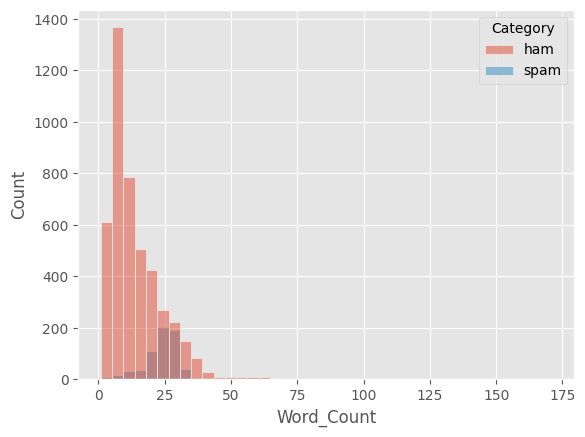

In [99]:
# plot word counts with historgram

sns.histplot(
    data = emails_df,
    x = "Word_Count",
    hue = "Category", 
    bins = 40
)

plt.show()

In [100]:
# average word count for each category

emails_df.groupby("Category")["Word_Count"].mean()

Category
ham     14.239814
spam    23.659906
Name: Word_Count, dtype: float64

In [101]:
# top 10 samples with smallest message length

emails_df.nsmallest(10, "Message_Length")

,Category,Message,Message_Length,Word_Count
1925,ham,Ok,2,1
3376,ham,:),2,1
261,ham,Yup,3,1
1612,ham,645,3,1
2182,ham,Ok.,3,1
287,ham,Ok..,4,1
2602,ham,Okie,4,1
5173,ham,U 2.,4,2
1273,ham,Ok...,5,1
4293,ham,G.W.R,5,1


In [102]:
# top 10 samples with largest message length

emails_df.nlargest(10, "Message_Length")

,Category,Message,Message_Length,Word_Count
1085,ham,For me the love should start with attraction.i...,910,171
1863,ham,The last thing i ever wanted to do was hurt yo...,790,162
2434,ham,Indians r poor but India is not a poor country...,629,109
1579,ham,How to Make a girl Happy? It's not at all diff...,611,103
2158,ham,Sad story of a Man - Last week was my b'day. M...,588,125
2380,ham,"Good evening Sir, hope you are having a nice d...",482,98
3017,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461,66
1513,ham,"Hey sweet, I was wondering when you had a mome...",458,95
2370,ham,A Boy loved a gal. He propsd bt she didnt mind...,446,96
2408,ham,Solve d Case : A Man Was Found Murdered On &l...,444,71


In [103]:
# random 5 samples with category spam

emails_df[emails_df["Category"] == "spam"].sample(5)

,Category,Message,Message_Length,Word_Count
2113,spam,You are a winner you have been specially selec...,157,28
837,spam,Do you want 750 anytime any network mins 150 t...,149,28
3766,spam,Someone U know has asked our dating service 2 ...,136,25
1154,spam,1000's of girls many local 2 u who r virgins 2...,139,30
2160,spam,FREE for 1st week! No1 Nokia tone 4 ur mob eve...,147,29


In [104]:
# random 5 samples with category ham

emails_df[emails_df["Category"] == "ham"].sample(5)

,Category,Message,Message_Length,Word_Count
5268,ham,"ER, ENJOYIN INDIANS AT THE MO..yeP. SaLL gOoD ...",80,16
4400,ham,Yes just finished watching days of our lives. ...,56,11
496,ham,Got meh... When?,16,3
1755,ham,How is your schedule next week? I am out of to...,62,13
5479,ham,Really do hope the work doesnt get stressful. ...,61,12


### 2.8 Data Preprocessing

### 2.8.1 Converting labels into numerical forms

Now, as we did some exploration with dataset and tried to add new features, we can start preprocessing which is the main part before modelling. In this step you need to prepare your dataset and make it suitable for the model to be trained on. First step related to this stage is to convert categories of interest into numerical forms. For simplicity, we will consider main columns of the dataset which are messages and labels. *We can use the new created features in our further discussion*. **However, it is highly recommended for you to implement this as practise**. 

As you know the categories in our dataset is labeled as ham and spam. It can not be understood by ML algorithm. For that reason we need to convert them into numerical form. In our example we can label ham messages as 0 and spam messages as 1. Let's realize our thoughts in code

**Exercise 10.** Convert `Category` to numbers: `ham` becomes 0 and `spam` becomes 1.

In [105]:
# Your code here: map ham to 0 and spam to 1 in the Category column
emails_df["Category"] = emails_df["Category"].map({
    "ham": 0,
    "spam": 1
})

In [106]:
emails_df.head()

,Category,Message,Message_Length,Word_Count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


### 2.8.2 Train Test split

In [107]:
import warnings
warnings.filterwarnings("ignore")

Now we can devide our dataset into 2 groups: 

1. training set which will be used to train model

2. test set which will be used to determine whether created model work fine or not. 

To divide dataset into train and test sets we will use sklearn's built-in method called train_test_split. Let's consider this function in code. We will first import it and then use it dividing 80% of our dataset into train and 20% into test sets. The given methods takes features and labels as separate inputs. So, before implementing this method we also need to assign our dataset features of interest (in our case messages) and labels into separate variables (such as X and y).

In [108]:
from sklearn.model_selection import train_test_split

**Exercise 11.** Set `X` to the messages and `y` to the category labels.

In [109]:
# Your code here: assign the Message column to X
X = emails_df["Message"]

In [110]:
# Your code here: assign the Category column to y
y = emails_df["Category"]

**Exercise 12.** Split `X` and `y` into training and test sets. Reserve 20% for testing and use `stratify=y`.

In [111]:
# Your code here: split X and y into X_train, X_test, y_train, y_test
# Use a 20% test set and stratify by y.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### 2.8.3 Converting messages into numerical forms

This stage includes converting message into numerical forms. As in the case of labels which was "Category" column of our dataset, "Message" column also contains text data. We need to convert these text messages into suitable numerical forms. For this purpose we will use build-in method called TfidfVectorizer. The low level understanding of this method is out of this lessons scope. However, as a passionate student you can learn more about this technique using the reference links and further research. For now all you need to know is that this method will create appropriate numerical data from our text messages. 

In [112]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

**Exercise 13.** Fit the provided TF–IDF vectorizer on training messages, then transform the test messages with the fitted vectorizer.

In [113]:
# Your code here: fit tfidf on X_train and save the result as X_train_tfidf
X_train_tfidf = tfidf.fit_transform(X_train)

In [114]:
# Your code here: transform X_test using the fitted tfidf and save it as X_test_tfidf
X_test_tfidf = tfidf.transform(X_test)

### 2.9 Modelling

We finally come to our main part: creating Models! We have all we need: inputs and outputs in the correct form. So, how to create suitable model? 


We can use ready functions from sklearn library. Sklearn is a huge library that contains almost every famous ML algorithm. In our case we will implement Logistic Regression. 

#### 2.9.1 Theoretical basics

<div align="center">
<img src="attachment:32611966-8c21-400a-8d07-cfc0fa772b20.jpeg" width="700"/>
</div>

Despite its name, logistic regression is a **classifier** here. It adds learned weights to the TF–IDF values and passes the result through a sigmoid:

$$P(\mathrm{spam}\mid x)=\frac{1}{1+e^{-(w\cdot x+b)}}.$$

The output is a number between 0 and 1. By default, scikit-learn predicts spam when this probability is at least 0.5 (this is considered as threshold). `max_iter=1000` is maximum steps that optimizer can use to converge; the actual number of steps may be smaller.

#### 2.9.2 Training

Let's firstly import model using sklearn and also import related accuracy metrics that we will use to measure the goodness of our model

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

Now we can define the model and train it. In general training is implemented with the help of fit method. 

In [116]:
model = LogisticRegression(max_iter=1000)

**Exercise 14.** Train the provided `model` using the vectorized training messages and labels.

In [117]:
# Your code here: train model on X_train_tfidf and y_train
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

That's it! It is very easy to train a model. 

**IMPORTANT NOTE:** *The challenging part is to explore and prepare data for modelling. If you don't know how to make good inputs and outputs, how to create usefull features and explore invaluable relations this steps will lose its meaning. So, as a student you need to focus mainly on all the steps before training!*

### 2.9.3 Test

As we have our model, we can test it. The model becomes useful when it give good or close to reality results on unseen data. Let's test our model. 

**Exercise 15.** Use the trained model to predict labels for the vectorized test messages.

In [118]:
# Your code here: predict labels for X_test_tfidf and save them as predictions
y_pred = model.predict(X_test_tfidf)

Now, let's calculate some metrics to measure how good our model is.

**Homework: try to explore what is the meaning of each metric and why they are used. What they measure?**

Accuracy is how many messages the model got right. I got 96.51% but most messages are ham so I also checked the other scores.

Precision was 97.92%. This means when the model says spam it is usually right.

Recall was 73.44% so the model did not find all the spam messages.

F1 was 83.93%. It combines precision and recall so it is useful to check both together.

The accuracy looks good but the model still misses some spam.

**Exercise 16.** Calculate accuracy, precision, recall, and F1 score in the next four cells.

In [119]:
# Your code here: calculate accuracy and save it as accuracy
# Display accuracy.
accuracy = accuracy_score(y_test, y_pred)

In [120]:
# Your code here: calculate precision and save it as precision
# Display precision.
precision = precision_score(y_test, y_pred)

In [121]:
# Your code here: calculate recall and save it as recall
# Display recall.
recall = recall_score(y_test, y_pred)

In [122]:
# Your code here: calculate F1 and save it as f1
# Display f1.
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9651162790697675
Precision: 0.9791666666666666
Recall: 0.734375
F1 Score: 0.8392857142857143


In [123]:
try: 
    auc = roc_auc_score(y_test, model.decision_function(X_test_tfidf))

except:
    try:
        auc = roc_auc_score(
            y_test,
            model.predict_proba(X_test_tfidf)[:, 1]
        )
    except:
        auc = np.nan

auc

0.9895818929756637

### 2.9.4 Confusion Matrix

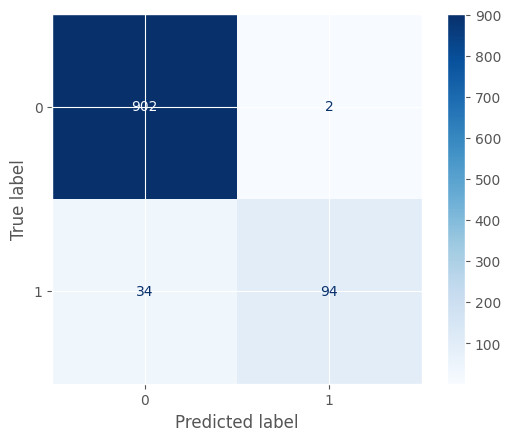

In [124]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.show()

### 2.10 Real world demo

In this section, we will explore the capacity of our model based on randomly created emails. For demonstration, several text messages were randomly created with label provided below:


**expected_labels = [ "spam", "ham", "spam", "ham", "spam", "ham", "spam", "ham", "ham"]**


You can also try to create your own sample and give to model. Let's explore the predictions and to get final thoughts.

**Exercise 17.** Transform the sample emails with the fitted vectorizer, then predict their labels.

In [125]:
emails = [
    "Congratulations! You've won a free phone. Claim your prize today.",
    
    "Hi, I uploaded the lecture notes to our shared folder.",
    
    "Limited-time offer! Get 90% off everything in our store.",
    
    "Are we still meeting tomorrow at 10 AM?",
    
    "You've been selected for a gift card. Reply to claim it.",
    
    "The project meeting has moved to Room 204.",
    
    "Earn easy money from home with this exclusive offer.",
    
    "Thanks for sending the draft. I'll review it tonight.",
        
    "Can you bring your laptop to class on Monday?",
]

# Your code here: use tfidf to transform emails into emails_vectorized
emails_vectorized = tfidf.transform(emails)

# Your code here: predict the sample labels and save them as predictions
predictions = model.predict(emails_vectorized)  

In [126]:
# print results 

for email, prediction in zip(emails, predictions):

    label = "Spam" if prediction == 1 else "Ham"

    print(f"Email : {email}")
    print(f"Label : {label}")
    print("-" * 60)

Email : Congratulations! You've won a free phone. Claim your prize today.
Label : Spam
------------------------------------------------------------
Email : Hi, I uploaded the lecture notes to our shared folder.
Label : Ham
------------------------------------------------------------
Email : Limited-time offer! Get 90% off everything in our store.
Label : Ham
------------------------------------------------------------
Email : Are we still meeting tomorrow at 10 AM?
Label : Ham
------------------------------------------------------------
Email : You've been selected for a gift card. Reply to claim it.
Label : Spam
------------------------------------------------------------
Email : The project meeting has moved to Room 204.
Label : Ham
------------------------------------------------------------
Email : Earn easy money from home with this exclusive offer.
Label : Ham
------------------------------------------------------------
Email : Thanks for sending the draft. I'll review it tonight

### 2.11 Final thoughts

What can we see here?

The demo shows that despite 96% accuracy our model mainly gives ham results. This is result of imbalanced datase that we discussed in previous sections: the model is biased to give ham results. So, question arises: how to solve this problem? 

**It will be your hometask!**  Do research related to this problem and try to find which methods and techniques can be used to solve this problem. Implement your thoughts and ideas as continuation of this notebook giving detailed explanations. This will help you to gain knowledge related to ML and also to understand difficult concepts. 

Selected threshold: 0.4457390629026822
Accuracy: 98.74%
Precision: 96.75%
Recall: 92.97%
F1: 94.82%
Spam detected: 119
Spam missed: 9
Ham incorrectly marked as spam: 4
Total mistakes: 13


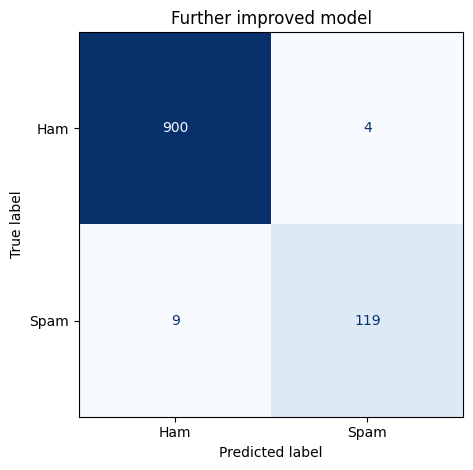

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict
)
from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

csv_path = Path("data") / "email.csv"

if not csv_path.is_file():
    csv_path = Path(
        r"C:\Users\User\OneDrive\Desktop\Lab_1\data\email.csv"
    )

df = pd.read_csv(csv_path)

df = df[df["Category"].isin(["ham", "spam"])].copy()
df = df.drop_duplicates()

X = df["Message"]
y = df["Category"].map({"ham": 0, "spam": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

features = FeatureUnion([
    ("word", TfidfVectorizer(
        ngram_range=(1, 3),
        min_df=2,
        max_features=50000,
        sublinear_tf=True
    )),
    ("char", TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(2, 5),
        min_df=2,
        max_features=60000,
        sublinear_tf=True
    ))
])

improved_model = Pipeline([
    ("features", features),
    ("lr", LogisticRegression(
        C=4,
        class_weight="balanced",
        solver="liblinear",
        max_iter=3000,
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_probabilities = cross_val_predict(
    improved_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=2
)[:, 1]

p, r, thresholds = precision_recall_curve(
    y_train,
    oof_probabilities
)

threshold_f1 = (
    2 * p[:-1] * r[:-1]
    / np.maximum(p[:-1] + r[:-1], 1e-12)
)

best_index = max(
    range(len(thresholds)),
    key=lambda i: (threshold_f1[i], p[i])
)

best_threshold = thresholds[best_index]

improved_model.fit(X_train, y_train)

test_probabilities = improved_model.predict_proba(X_test)[:, 1]

improved_pred = (
    test_probabilities >= best_threshold
).astype(int)

accuracy = accuracy_score(y_test, improved_pred)
precision = precision_score(y_test, improved_pred, zero_division=0)
recall = recall_score(y_test, improved_pred, zero_division=0)
f1 = f1_score(y_test, improved_pred, zero_division=0)

cm = confusion_matrix(
    y_test,
    improved_pred,
    labels=[0, 1]
)

tn, fp, fn, tp = cm.ravel()

print("Selected threshold:", best_threshold)
print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1: {f1:.2%}")
print("Spam detected:", tp)
print("Spam missed:", fn)
print("Ham incorrectly marked as spam:", fp)
print("Total mistakes:", fp + fn)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues", colorbar=False)

plt.title("Further improved model")
plt.tight_layout()
plt.show()

The dataset contains more ham messages than spam messages. The training set included 3612 ham messages and 513 spam messages, so I evaluated precision, recall and F1 alongside accuracy.
I used Logistic Regression with class_weight="balanced" to give greater weight to the less frequent spam class during training. The model used C=4 to control regularization.
I combined word and character TF-IDF features. Word features included single words and sequences of up to three words. Character features used sequences of two to five characters with the char_wb analyzer. This combination captures both short phrases and parts of words.
The data was split into 80% training and 20% testing, preserving the class proportions through stratification. I used five-fold stratified cross-validation within the training set to generate out-of-fold probabilities. TF-IDF was included in the pipeline and fitted separately within each training fold.
I selected the threshold that maximized F1 on the training out-of-fold predictions. The selected threshold was approximately 0.446. I then fitted the pipeline on the full training set and calculated the evaluation metrics on the test split.

The model achieved:
Accuracy: 98.74%
Precision: 96.75%
Recall: 92.97%
F1: 94.82%

It correctly detected 119 out of 128 spam messages. Nine spam messages were missed, and four ham messages were classified as spam, giving 13 incorrect predictions in total.
These results summarize the model’s performance on the evaluated dataset split.
Sources:

- [Class weights and regularization](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [TF-IDF features](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)
- [Decision threshold selection](https://scikit-learn.org/stable/modules/classification_threshold.html)

### 2.12 Summary:

In this project we mainly learned:


1. How to import and get basic knowledge about dataset


2. How to Explore data and create new features


3. How to make visualizations such as pie-charts, bargraph, historgram etc.


4. How to preprocesses data 


5. How to train and test data. How to create model



You will learn a lot more by trying to implement this techniques on new datasets. I highly recommend you to search for dataset that has similar format as this and implement this techniques on your dataset. Fell free to share your results with teachers and your friends. Explore interesting concepts and apply them to your own notebook. Don't fear to make mistakes, just try to do your best. 


GOOD LUCK!

### References

If you prefer to watch some videos and tutorials pls consider this. It contains 90% of this notebook as code examples. 

- https://www.youtube.com/watch?v=B1S6J_KmujU&t=2250s

For numpy consider its documentation.

- https://numpy.org/doc/stable/user/absolute_beginners.html

For pandas.

- https://numpy.org/doc/stable/user/absolute_beginners.html

For scikit-learn.

- https://scikit-learn.org/stable/getting_started.html

- https://www.youtube.com/watch?v=SIEaLBXr0rk

If you have difficulties in theory of Logistic Regression pls consider this materials

- https://www.youtube.com/watch?v=zM4VZR0px8E
